# Проект спринта: анализ клиентов сети фитнес-центров

Сеть фитнес-центров «Культурист-датасаентист» разрабатывает стратегию взаимодействия с клиентами на основе аналитических данных.

Распространённая проблема фитнес-клубов и других сервисов — отток клиентов. Как понять, что клиент больше не с вами? Можно записать в отток тех, кто попросил закрыть договор или удалил аккаунт. Однако клиенты не всегда уходят демонстративно: чаще они перестают пользоваться сервисом тихо.

Индикаторы оттока зависят от специфики отрасли. Когда пользователь редко, но стабильно закупается в интернет-магазине — не похоже, что он «отвалился». А вот если две недели не заходит на канал с ежедневно обновляемым контентом, дела плохи: подписчик заскучал.

Для фитнес-центра можно считать, что клиент попал в отток, если за последний месяц он ни разу не посетил спортзал. Конечно, не исключено, что он уехал в отпуск и по приезде обязательно продолжит ходить на тренировки. Однако чаще всего такое отсутствие говорит об окончательном уходе. Если клиент начал новую жизнь с понедельника, немного походил в зал, а потом пропал — скорее всего, он уже не вернётся.

Чтобы бороться с оттоком, отдел по работе с клиентами «Культуриста-датасаентиста» перевёл в электронный вид множество клиентских анкет. Ваша задача — провести анализ и подготовить план действий по удержанию клиентов.

Что предстоит сделать:

- Научиться прогнозировать вероятность оттока (на уровне следующего месяца) для каждого клиента.

- Сформировать типичные портреты пользователей: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства.

- Проанализировать основные признаки, наиболее сильно влияющие на отток.

- Сформулировать основные выводы разработать рекомендации по повышению качества работы с клиентами: выделить целевые группы, предложить меры по снижению оттока.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import accuracy_score, precision_score, recall_score



pd.set_option('display.precision', 15)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 300)

## Шаг 1. Загрузите данные

Заказчик подготовил CSV-файл, который содержит данные на месяц до оттока и факт оттока на определённый месяц. Путь к файлу: `'https://code.s3.yandex.net/datasets/gym_churn.csv'`.

Набор данных включает следующие поля:

- `Churn` — факт оттока в текущем месяце.

- Данные пользователя за месяц до проверки факта оттока:

   - `gender`  — пол: `1` — женский, `0` — мужской.

   - `Near_Location` — проживание или работа в районе фитнес-центра: `1` — да, `0` — нет.

   - `Partner` — сотрудник компании — партнёра клуба (может получить корпоративную скидку): `1` — да, `0` — нет.

   - `Promo_friends` — запись по акции «Приведи друга» (использован промокод): `1` — да, `0` — нет.

   - `Phone` — наличие контактного телефона: `1` — да, `0` — нет.

   - `Age` — возраст.

   - `Lifetime` — время с момента первого обращения в фитнес-центр в месяцах.

- Информация на основе журнала посещений, покупок и информация о текущем статусе абонемента клиента:

   - `Contract_period` — длительность текущего действующего абонемента (1, 3, 6 или 12 месяцев).

   - `Month_to_end_contract` — срок до окончания текущего действующего абонемента в месяцах.

   - `Group_visits` — факт посещения групповых занятий.

   - `Avg_class_frequency_total` — средняя частота посещений в неделю за всё время с начала действия абонемента.

   - `Avg_class_frequency_current_month` — средняя частота посещений в неделю за предыдущий месяц.

   - `Avg_additional_charges_total` — суммарная выручка от других услуг фитнес-центра: кафе, спорттовары, косметический и массажный салоны.

In [3]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/gym_churn.csv')

## Шаг 2. Проведите исследовательский анализ данных (EDA)

Для проведения EDA выполните как минимум следующие действия:

- Посмотрите на датасет: есть ли в нём отсутствующие признаки? Изучите средние значения и стандартные отклонения — здесь пригодится метод `describe()`.

- Посмотрите на средние значения признаков в двух группах — тех, кто ушёл в отток, и тех, кто остался. Используйте метод `groupby()`.

- Постройте матрицу корреляций и визуализируйте её.

Сделайте промежуточные выводы: что уже можно сказать про эти данные?

In [4]:
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


- Датасет содержит 4000 клиентов, пропусков не выявлено. 
- Явных выбросов и аномалий по описательной статистике не видно. 
- Доля оттока в выборке — ~26.5% (Churn mean = 0.265), т.е. в выборке примерно в 3 раза больше тех, кто остался, чем тех, кто ушёл. Это дисбаланс классов, который стоит учитывать при обучении и оценке модели (одной accuracy будет недостаточно, нужны precision/recall).

In [5]:
df.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


Отток характерен для клиентов, которые пришли недавно (стаж около 1 месяца против 4.7), взяли короткий абонемент ( около 1.7 против 5.7 месяца) и заметно снизили или изначально держали низкую частоту посещений (около 1 против 2 раз в неделю). Также заметна небольшая возрастная разница (27 против 30 лет).

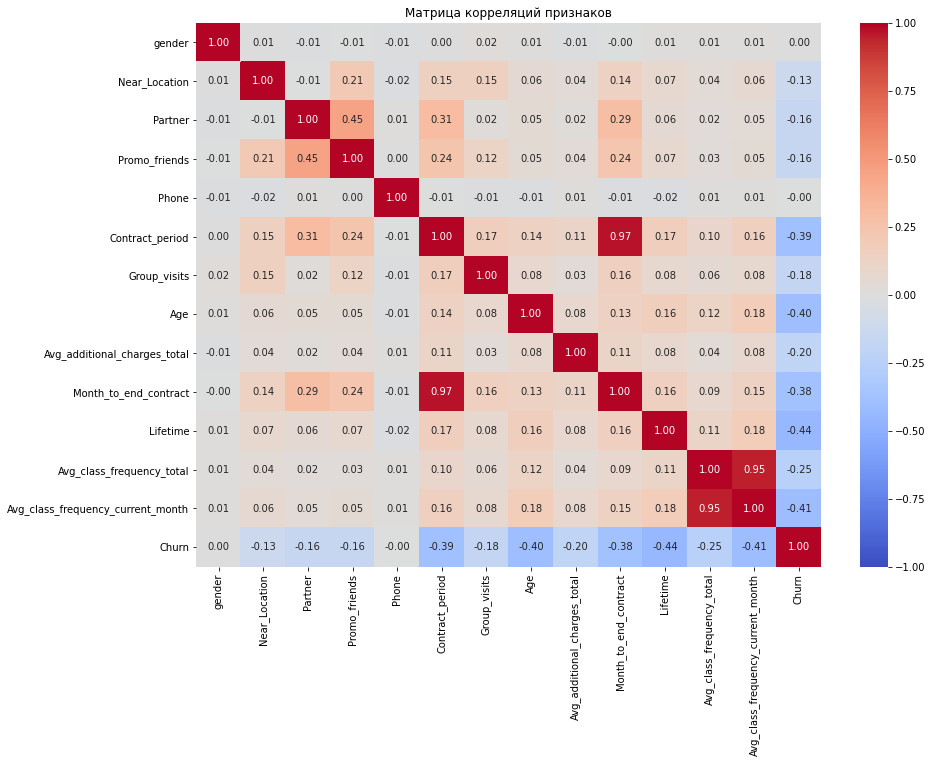

In [6]:
cm = df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций признаков')
plt.show()

- Сильная связь между парами признаков (мультиколлинеарность): Contract_period - Month_to_end_contract (0.97), Avg_class_frequency_total - Avg_class_frequency_current_month (0.95) - один из каждой пары стоит убрать перед линейной моделью
- Сильнее всего с оттоком связаны: Lifetime, Age, Avg_class_frequency_current_month, Contract_period — все отрицательно (чем больше значение, тем меньше риск ухода)

Промежуточный вывод: Группа риска — это относительно молодой клиент с небольшим стажем посещения, коротким абонементом и снизившейся или низкой частотой посещений в последний месяц. 




## Шаг 3. Постройте модель прогнозирования оттока пользователей

Постройте модель бинарной классификации пользователей, где целевой признак — факт оттока (Churn) в следующем месяце:

- Разбейте данные на обучающую и тестовую выборки функцией `train_test_split()`.

- Обучите модель на train-выборке алгоритмом «случайный лес» (Random Forest).

- Оцените метрики `accuracy`, `precision` и `recall` на тестовой выборке.

- Опишите, как интерпретировать полученные значения метрик.

Не забудьте указать параметр random_state при разделении выборки и инициализации алгоритма, чтобы ваши результаты были воспроизводимы.

In [7]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
scaler = StandardScaler()
X_train_st = scaler.fit_transform(X_train)
X_test_st = scaler.transform(X_test)

In [10]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_st, y_train)

RandomForestClassifier(random_state=42)

In [11]:
predictions = rf_model.predict(X_test_st)

In [12]:
print(f'Accuracy: {accuracy_score(y_test, predictions):.2f}')
print(f'Precision: {precision_score(y_test, predictions):.2f}')
print(f'Recall: {recall_score(y_test, predictions):.2f}')

Accuracy: 0.93
Precision: 0.89
Recall: 0.83


- Модель: Random Forest
- Accuracy = 0.93 — 93% всех клиентов классифицированы верно
- Precision = 0.89 — из тех, кого модель отнесла к "уйдёт", 89% ушли реально (мало ложных тревог)
- Recall = 0.83 — из реально ушедших клиентов модель заранее выявила 83% (17% пропустила)
- Модель хорошо находит клиентов группы риска, но не идеально — часть уходящих клиентов (~17%) остаётся незамеченной

## Шаг 4. Сделайте кластеризацию пользователей

Отложите в сторону столбец с оттоком и проведите кластеризацию самих объектов (пользователей):

- Стандартизируйте данные.

- Постройте матрицу расстояний функцией `linkage()` на стандартизованной матрице признаков и нарисуйте дендрограмму. Обратите внимание, что отрисовка дендрограммы может занять время. Можно ли по графику предположить, какое количество кластеров стоит выбрать?

- Обучите модель кластеризации на основе алгоритма K-Means и спрогнозируйте кластеры клиентов. Договоримся за число кластеров принять 5, чтобы ваши результаты можно было сравнивать с результатами остальных студентов, хотя в реальной жизни правильный ответ и решение всегда остаются за вами.

- Посмотрите на средние значения признаков для кластеров. Можно ли сразу заметить какие-то закономерности?

- Для каждого полученного кластера посчитайте долю оттока методом `groupby()`. Различаются ли они? Какие кластеры наиболее склонны к оттоку, а какие — самые надёжные?


In [13]:
X_clust = df.drop('Churn', axis=1)
scaler = StandardScaler()
X_clust_st = scaler.fit_transform(X_clust)

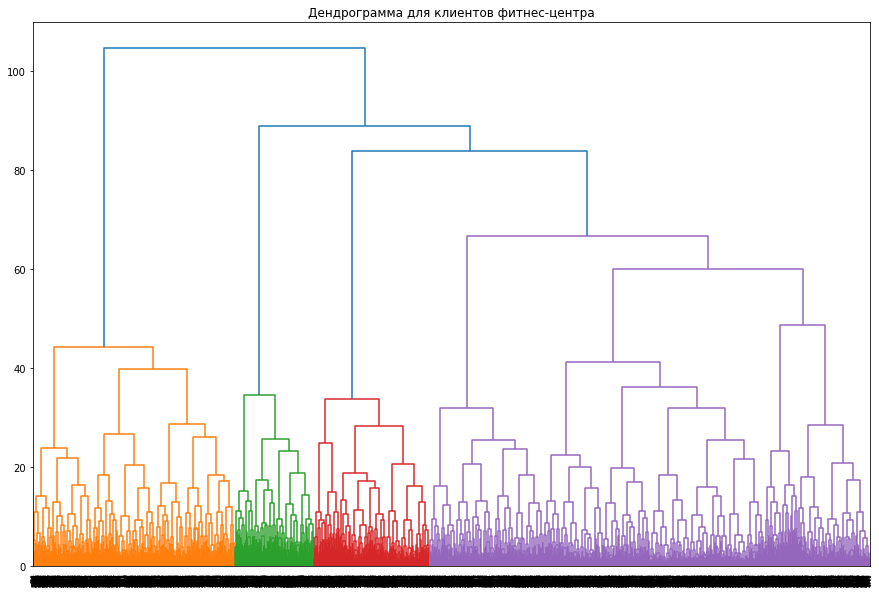

In [14]:
linked = linkage(X_clust_st, method='ward')

plt.figure(figsize=(15, 10))
dendrogram(linked, orientation='top')
plt.title('Дендрограмма для клиентов фитнес-центра')
plt.show()

In [15]:
km = KMeans(n_clusters=5, random_state=0)
labels = km.fit_predict(X_clust_st)

df['cluster_km'] = labels

In [16]:
df.groupby('cluster_km').mean()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster_km,,,,,,,,,,,,,,
0,0.502970,0.959406,0.783168,0.574257,1.000000,10.889109,0.542574,29.982178,160.761016,9.954455,4.736634,1.982055,1.974789,0.027723
1,0.522078,0.862338,0.470130,0.306494,0.000000,4.787013,0.425974,29.301299,143.957664,4.475325,3.924675,1.847220,1.716369,0.267532
2,0.495050,0.000000,0.463366,0.079208,1.000000,2.352475,0.215842,28.477228,135.457501,2.198020,2.809901,1.660461,1.477324,0.443564
3,0.485737,1.000000,0.350238,0.240095,1.000000,1.948494,0.341521,28.167987,131.622204,1.856577,2.440571,1.247634,1.012983,0.514263
4,0.559666,0.976134,0.356802,0.230310,0.998807,2.669451,0.473747,30.125298,161.657905,2.459427,4.898568,2.852002,2.850161,0.068019


- Кластер 0 — самые надёжные: длинный абонемент (примерно 11 мес), долгий стаж (4.7 мес), высокая частота посещений, живут рядом с клубом (Near_Location = 0.96)
- Кластер 4 — активные и надёжные: самая высокая частота посещений (2.85 раз/нед), большой стаж (4.9 мес), хотя короткий текущий абонемент
- Кластер 2 — живут далеко от клуба (Near_Location = 0), короткий абонемент, низкая частота посещений
- Кластер 3 — самый короткий абонемент (около 1.9 мес), самый маленький стаж (2.4 мес), самая низкая частота посещений (1.0 раз/нед)


In [17]:
df.groupby('cluster_km')['Churn'].mean().sort_values(ascending=False)

cluster_km
3    0.514263
2    0.443564
1    0.267532
4    0.068019
0    0.027723
Name: Churn, dtype: float64

Наиболее склонны к оттоку: 
Класс 3 - 51.4% (короткий абонемент, малый стаж, редко посещвают)
Класс 2 - 44.4% (живут далеко, короткий абонемент)

Надежные: 
Класс 4 - 6.8% (часто посещают, большой стаж)
Класс 0 - 2.8%	(длинный абонемент, живут рядом, постоянные)

Риск оттока напрямую связан со сроком абонемента, стажем и частотой посещений. 
Дополнительно кластеризация выявила новый фактор — территориальную близость к клубу (кластер 2 целиком состоит из "удалённых" клиентов и попадает в зону риска).

## Шаг 5. Сформулируйте выводы и сделайте базовые рекомендации по работе с клиентами

Сформулируйте основные выводы исследования и предложите рекомендации для стратегии взаимодействия с пользователями и их удержания. Не нужно описывать стратегию слишком детально: достаточно выделить 3–4 важных принципа и привести примеры их реализации в виде определённых маркетинговых действий.

Основные выводы: 
- Отток ~26.5%, классы несбалансированы — при оценке модели одной accuracy недостаточно
- Портрет клиента группы риска — молодой (около 27 лет), недавно пришёл (стаж 1 мес), короткий абонемент (около 1.7 мес), редко посещал зал в последний месяц (1 раз/нед)
- Модель Random Forest предсказывает отток с accuracy 0.93, precision 0.89, recall 0.83 — хорошо находит рисковых клиентов, но ~17% пропускает
- Кластеризация выявила 5 групп с сильно разной долей оттока (от 2.8% до 51.4%), подтвердив главные факторы риска: короткий абонемент, малый стаж, редкие посещения — и добавила новый фактор: удалённость от клуба (кластер 2 живёт не рядом и в зоне риска)

Рекомендации:

1. Удержание в первые месяцы: Самый рисковый период — начало членства (стаж < 2 мес). Пример действия: welcome-программа с персональным сопровождением тренера первые 4 недели.

2. Мотивация к длинным абонементам: Короткие абонементы (1 мес) коррелируют с высоким оттоком. Пример действия: скидка или бонус (например, доп. занятие) при переходе с 1-месячного на 3- или 6-месячный абонемент.

3. Стимулирование регулярности посещений : Снижение частоты посещений — ранний сигнал риска. Пример действия: автоматическое уведомление/предложение (скидка на доп. услуги) клиенту, который не был в зале 10+ дней подряд.

4. Работа с удалённым сегментом (кластер 2): Клиенты не рядом с клубом — отдельная зона риска. Пример действия: акцент на групповых занятиях и удобном расписании для этого сегмента, либо партнёрство с транспортными сервисами / парковка.
